### Make figure for CSD of connectivity-based labeling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, generate_binary_structure, binary_erosion
from skimage.morphology import binary_opening
from skimage.measure import regionprops, marching_cubes, mesh_surface_area
import napari
from matplotlib.animation import FuncAnimation
import nibabel as nib
from tqdm.auto import tqdm
plt.rcParams['font.family'] = 'Arial'

/Users/caj/Desktop/GitHub/capsule-software/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = np.load("../Stelzer_Torsten/npys/sh_removed_1a.npy")

In [3]:
idx = 500
slice_raw = data[idx, :, :].copy()

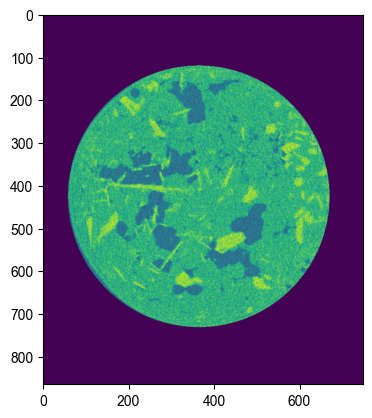

In [4]:
plt.imshow(slice_raw)

In [5]:
del data
data = np.load("../Stelzer_Torsten/npys/capsule_1a.npy") == 2

Draw a circle around the capsule to make the plots look nicer

In [6]:
def label_to_rgb(label_img, seed=0):
    np.random.seed(seed)
    labels = np.unique(label_img)
    colors = np.random.rand(labels.max() + 1, 3)  # RGB values 0–1
    colors[0] = 1  # background = black
    rgb_img = colors[label_img]
    return rgb_img

In [7]:
labeled, n_labels = label(data, generate_binary_structure(3, 1))

In [8]:
# napari.view_image(data)

In [9]:
%gui qt6
# napari.view_image(labeled)

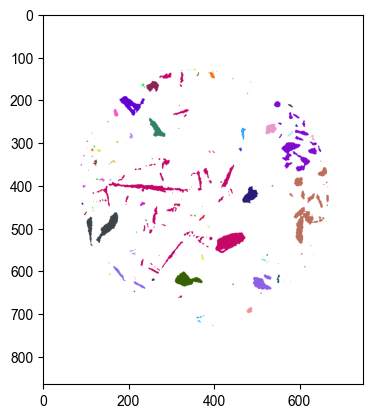

In [10]:
slice_conn = label_to_rgb(labeled[500, :, :])
plt.imshow(slice_conn)

Get CSD

In [11]:
sizes = np.bincount(labeled.ravel())[1:] #drop background
sizes

array([5393780,       4,    2060, ...,      17,       4,       3],
      shape=(12804,))

In [12]:
sizes = np.sort(sizes)
sizes

array([      1,       1,       1, ...,  985090, 2903928, 5393780],
      shape=(12804,))

In [13]:
volumes_conn = sizes * (15e-3)**3
volumes_conn

array([3.37500000e-06, 3.37500000e-06, 3.37500000e-06, ...,
       3.32467875e+00, 9.80075700e+00, 1.82040075e+01], shape=(12804,))

In [14]:
np.sort(volumes_conn)

array([3.37500000e-06, 3.37500000e-06, 3.37500000e-06, ...,
       3.32467875e+00, 9.80075700e+00, 1.82040075e+01], shape=(12804,))

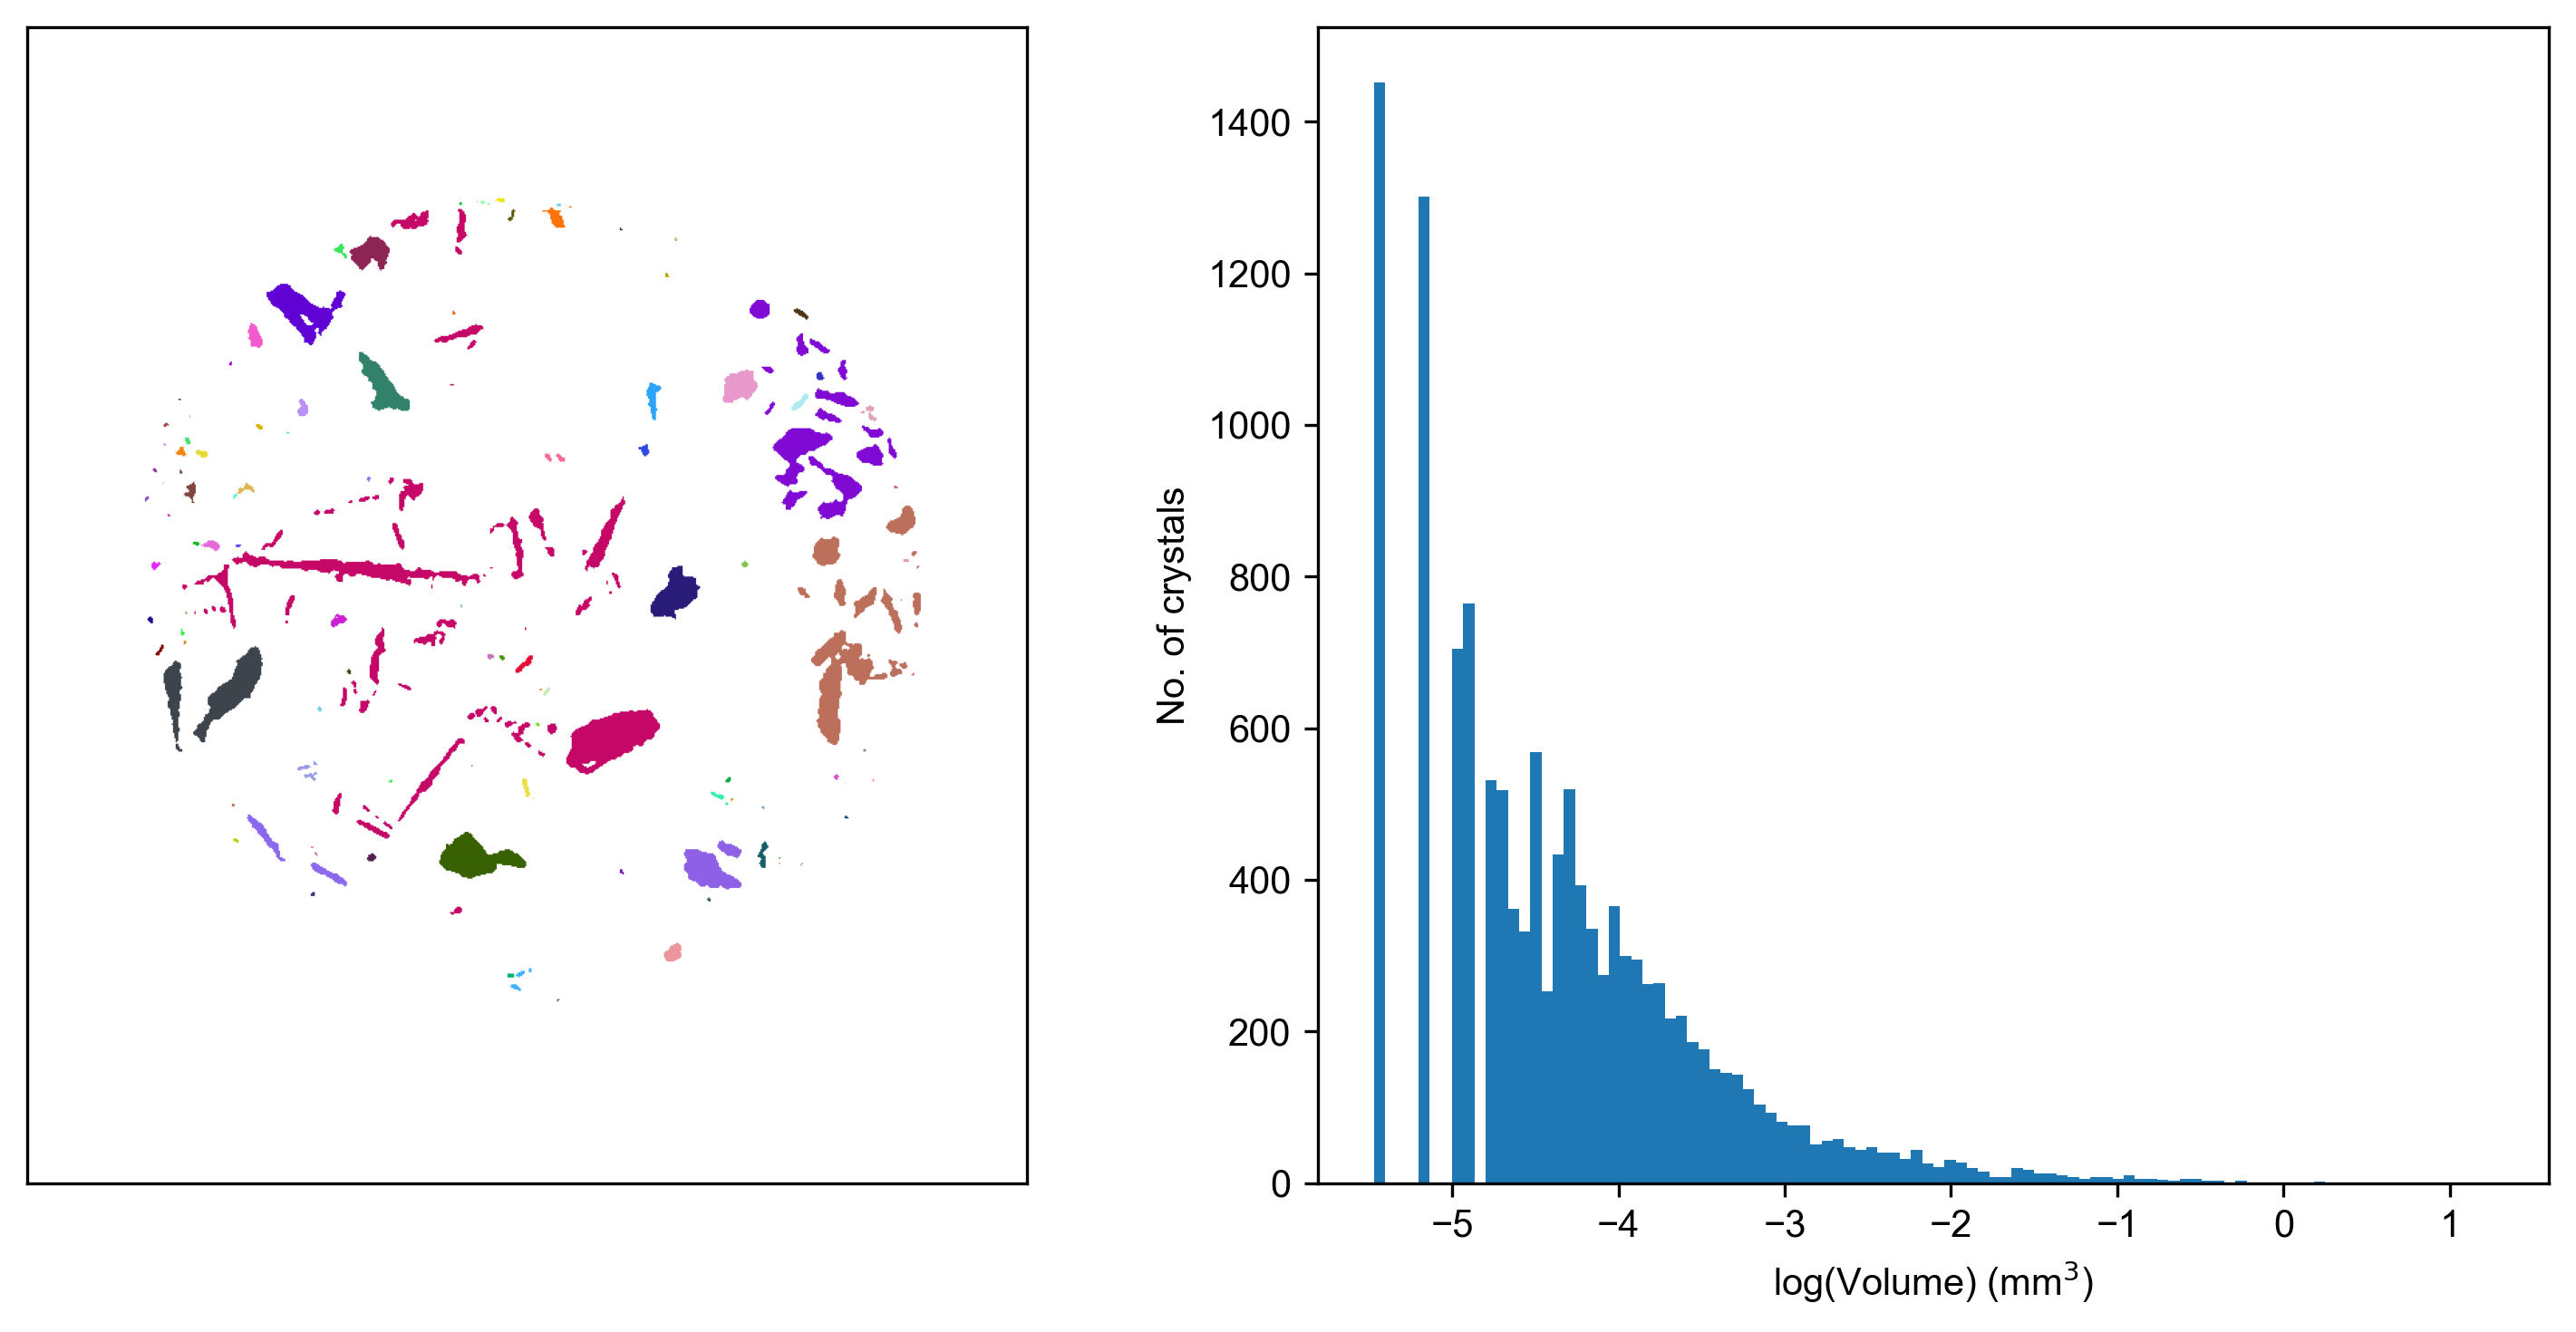

In [15]:
fig, axs = plt.subplots(1, 2, dpi=300, figsize=(10, 5))
axs[0].imshow(label_to_rgb(labeled[500, :, :]))
axs[0].set_xticks([])
axs[0].set_yticks([])

axs[1].hist(np.log10(volumes_conn), bins=100)
axs[1].set_ylabel("No. of crystals")
axs[1].set_xlabel("log(Volume) (mm$^3$)")
fig.tight_layout()
# fig.savefig("imgs/4_connectivity_CSD.png", dpi=300)

Connectivity labeling done, now need to do erosion

In [16]:
s = generate_binary_structure(3, 1)
data = binary_erosion(data, s)
data = binary_erosion(data, s)

In [17]:
labeled, n_labels = label(data, generate_binary_structure(3, 1))

In [18]:
slice_eroded = label_to_rgb(labeled[500, :, :])

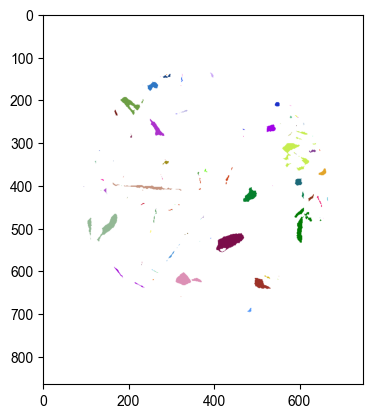

In [19]:
plt.imshow(slice_eroded)

In [20]:
sizes = np.bincount(labeled.ravel())[1:] #drop background
sizes = np.sort(sizes)
volumes_eroded = sizes * (15e-3)**3
volumes_eroded
np.sort(volumes_eroded)

array([3.37500000e-06, 3.37500000e-06, 3.37500000e-06, ...,
       1.12593037e+00, 1.17866812e+00, 6.98286150e+00], shape=(22416,))

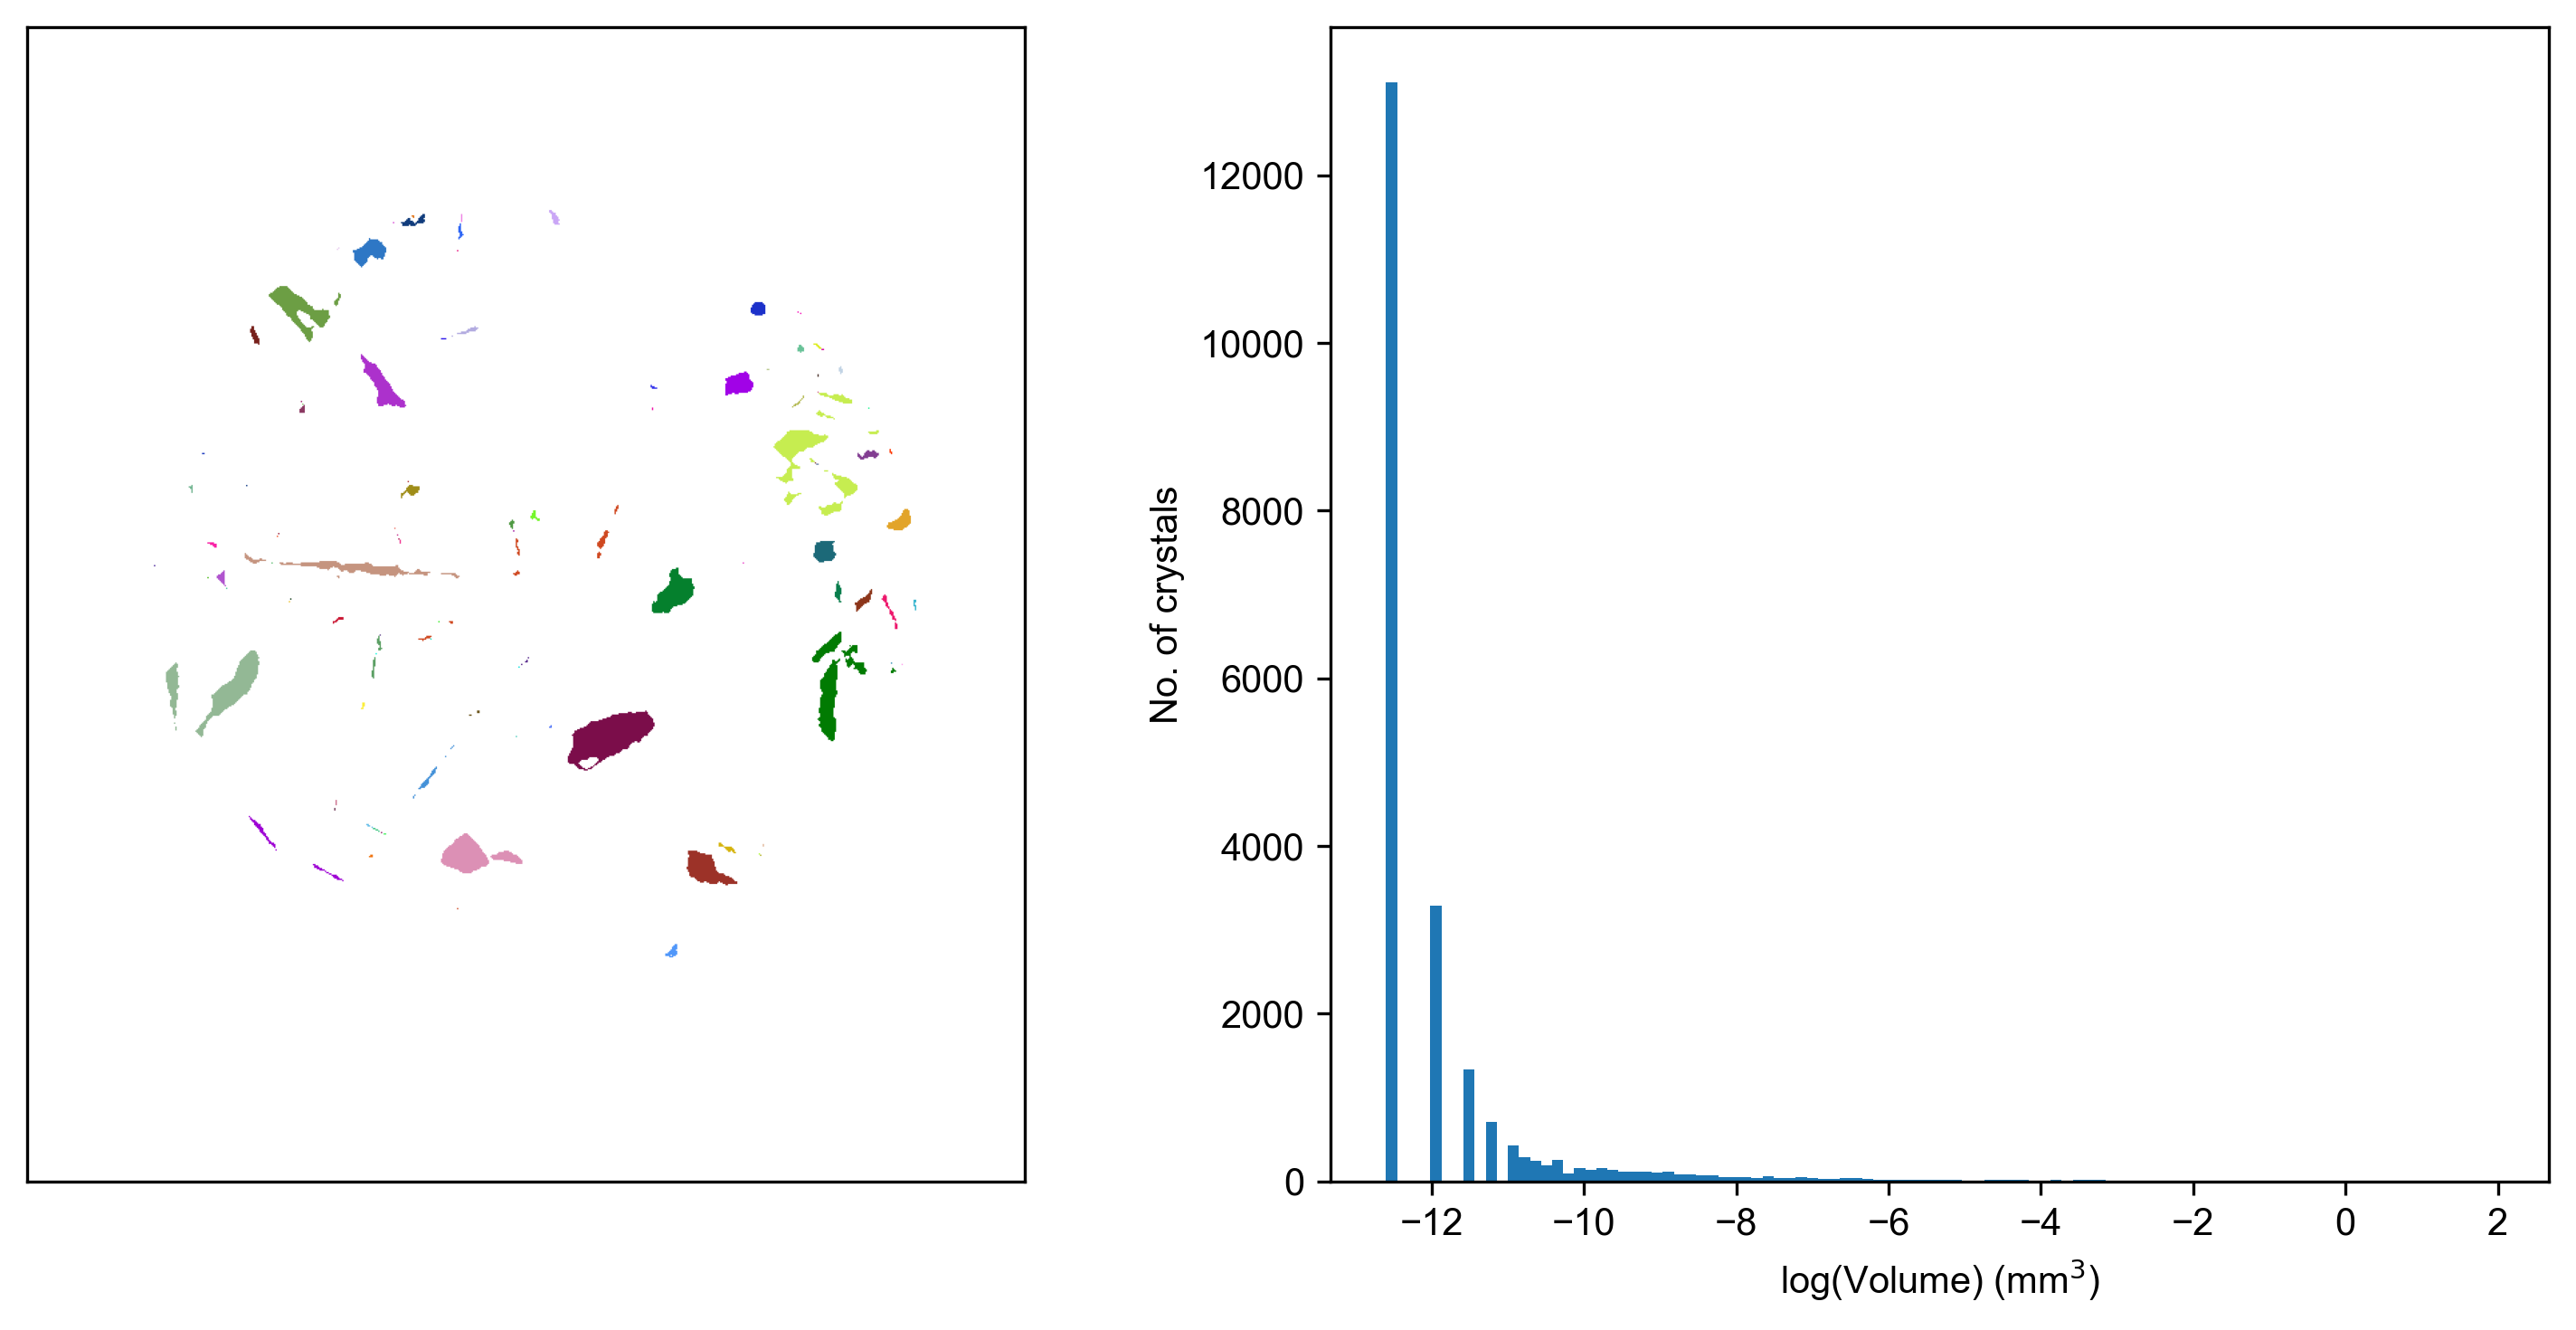

In [21]:
fig, axs = plt.subplots(1, 2, dpi=300, figsize=(10, 5))
axs[0].imshow(slice_eroded)
axs[0].set_xticks([])
axs[0].set_yticks([])

axs[1].hist(np.log(volumes_eroded), bins=100)
axs[1].set_ylabel("No. of crystals")
axs[1].set_xlabel("log(Volume) (mm$^3$)")
fig.tight_layout()

Now visualize the watershed

In [22]:
del data
del labeled

In [23]:
watershed = np.load("labeled_crystals.npy")

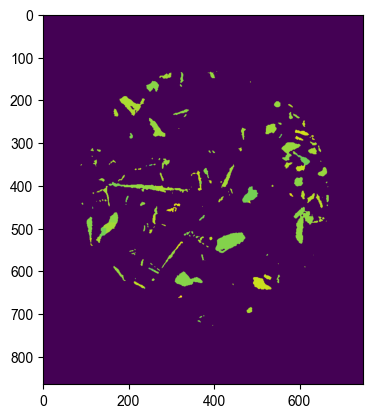

In [24]:
plt.imshow(watershed[500, :, :])

In [25]:
sizes = np.bincount(watershed.ravel())[1:] #drop background
sizes = np.sort(sizes)
volumes_watershed = sizes * (15e-3)**3
volumes_watershed
np.sort(volumes_watershed)

array([3.37500000e-06, 3.37500000e-06, 3.37500000e-06, ...,
       5.15203875e-01, 5.21906625e-01, 5.79636000e-01], shape=(3144,))

In [26]:
slice_watershed = label_to_rgb(watershed[500, :, :])

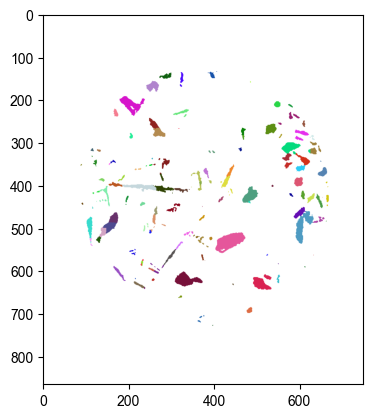

In [27]:
plt.imshow(slice_watershed)

In [28]:
# napari.view_image(label_to_rgb(watershed))

Final figure

In [29]:
def make_translucent(slice):
    alpha_channel = np.full(slice.shape[:2], 255)
    white_mask = (slice[..., 0] == 1) & \
                 (slice[..., 1] == 1) & \
                 (slice[..., 2] == 1)
    
    alpha_channel[white_mask] = 0
    slice_translucent = np.dstack([slice, alpha_channel])
    return slice_translucent

In [30]:
slice_conn[0, 0, :]

array([1., 1., 1.])

In [31]:
slice_conn.shape

(865, 748, 3)

In [32]:
slice_conn.shape

(865, 748, 3)

In [33]:
slice_conn_translucent = make_translucent(slice_conn)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


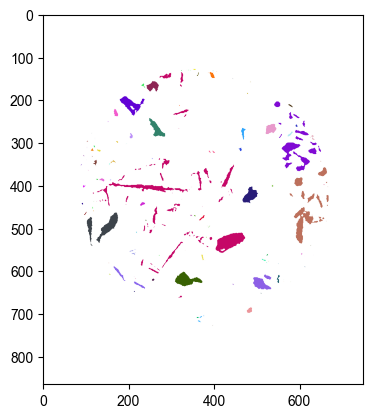

In [34]:
plt.imshow(slice_conn_translucent)

In [35]:
make_translucent(slice_raw).shape

(865, 748, 2)

In [36]:
slice_raw.shape

(865, 748)

In [37]:
slice_raw[slice_raw == -1] = np.max(slice_raw)

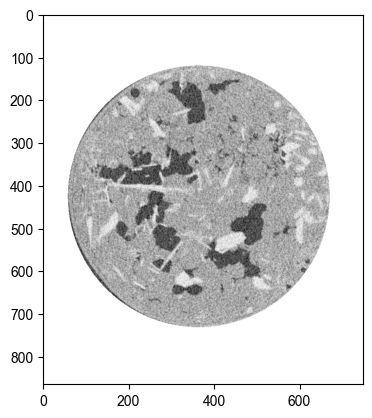

In [38]:
plt.imshow(slice_raw, cmap='Greys_r')

/var/folders/xl/5_smmts55rzdk3jp8m7mrrmw0000gn/T/ipykernel_54081/1632526582.py:25: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([0, 10**4])
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
/var/folders/xl/5_smmts55rzdk3jp8m7mrrmw0000gn/T/ipykernel_54081/1632526582.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


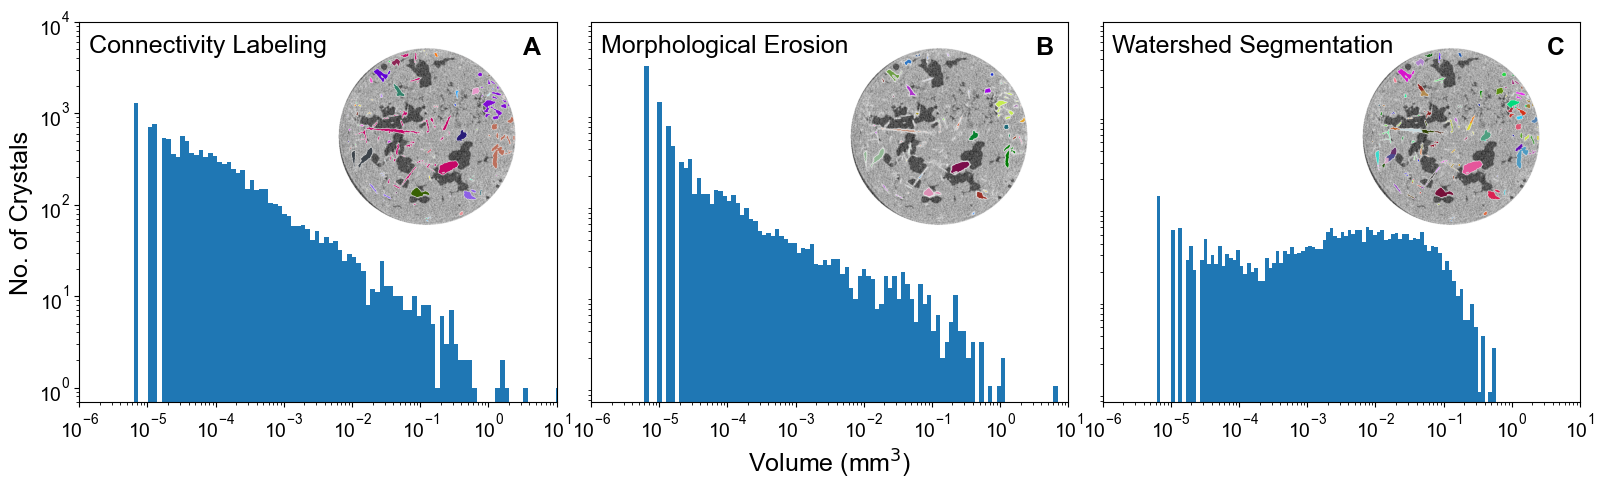

In [39]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# axs[0, 0].axis('off')
# axs[2, 0].axis('off')
    
# for ax, img in zip([axs[0, 1], axs[1, 1], axs[2, 1]],
#                    [slice_conn, slice_eroded, slice_watershed]):
#     ax.imshow(slice_raw, zorder=1, cmap='Greys_r')
#     ax.imshow(make_translucent(img), zorder=2)

titles = ['Connectivity Labeling', 'Morphological Erosion', 'Watershed Segmentation']

for ax, csd, title, img in zip(axs, 
                               [volumes_conn, volumes_eroded, volumes_watershed], 
                               titles,
                               [slice_conn, slice_eroded, slice_watershed]):
    
    min_val = csd.min()
    max_val = csd.max()
    bins = np.logspace(np.log10(min_val), np.log10(max_val), 100)
    ax.hist(csd, bins=bins, log=True)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_ylim([0, 10**4])
    ax.set_xlim([10**-6, 10])
    ax.set_xscale('log')
    
    axins = inset_axes(ax, width="53%", height="53%", loc='upper right')
    axins.axis('off')
    axins.imshow(make_translucent(slice_raw)[50:750, 0:700, 0], zorder=2, cmap='Greys_r')
    axins.imshow(make_translucent(img[50:750, 0:700]), zorder=3)
    ax.set_title(title, ha='left', x=0.02, y=0.9, fontsize=18, zorder=10)
    ax.set_facecolor('none')
    ax.set_zorder(10)

axs[1].set_yticks([])
axs[2].set_yticks([])
axs[1].set_xlabel("Volume (mm$^3$)", fontsize=18)
axs[0].set_ylabel("No. of Crystals", fontsize=18)

fig.text(0.33, 0.88, "A", fontsize=18, fontweight='bold')
fig.text(0.65, 0.88, "B", fontsize=18, fontweight='bold')
fig.text(0.97, 0.88, "C", fontsize=18, fontweight='bold')

fig.tight_layout()
fig.savefig("imgs/4_CSD_comparison.png", dpi=300)

Get spherical equivalent diameter and isoperimetric quotient

In [40]:
volumes_watershed

array([3.37500000e-06, 3.37500000e-06, 3.37500000e-06, ...,
       5.15203875e-01, 5.21906625e-01, 5.79636000e-01], shape=(3144,))

In [41]:
diameters = (6 * volumes_watershed / np.pi)**(1/3) * 10**3 # Convert mm to microns
d10 = np.percentile(diameters, 10)
d50 = np.percentile(diameters, 50)
d90 = np.percentile(diameters, 90)
span = (d90 - d10) / d50
span

np.float64(2.569457360592278)

In [ ]:
import numpy as np
import math

def compute_all_iqs_fast(labeled_image, voxel_spacing=15e-3):

    face_area = voxel_spacing ** 2
    voxel_vol = voxel_spacing ** 3
    max_label = labeled_image.max()
    
    voxel_counts = np.bincount(labeled_image.ravel(), minlength=max_label + 1)
    volumes = voxel_counts * voxel_vol

    total_faces = np.zeros(max_label + 1, dtype=np.int64)

    def add_faces(labels_array):
        counts = np.bincount(labels_array.ravel(), minlength=max_label + 1)
        total_faces[:] += counts

    z1, z2 = labeled_image[:-1, :, :], labeled_image[1:, :, :]
    mask_z = (z1 != z2)
    add_faces(z1[mask_z])
    add_faces(z2[mask_z])

    y1, y2 = labeled_image[:, :-1, :], labeled_image[:, 1:, :]
    mask_y = (y1 != y2)
    add_faces(y1[mask_y])
    add_faces(y2[mask_y])

    x1, x2 = labeled_image[:, :, :-1], labeled_image[:, :, 1:]
    mask_x = (x1 != x2)
    add_faces(x1[mask_x])
    add_faces(x2[mask_x])

    add_faces(labeled_image[0, :, :])
    add_faces(labeled_image[-1, :, :])
    add_faces(labeled_image[:, 0, :])
    add_faces(labeled_image[:, -1, :])
    add_faces(labeled_image[:, :, 0])
    add_faces(labeled_image[:, :, -1])

    surface_areas = total_faces * face_area

    iqs = np.zeros_like(volumes, dtype=np.float64)
    
    valid = surface_areas > 0 
    iqs[valid] = (36 * math.pi * (volumes[valid] ** 2)) / (surface_areas[valid] ** 3)
    
    return {
        label: iqs[label] 
        for label in range(1, max_label + 1) 
        if voxel_counts[label] > 0
    }

In [43]:
iqs = compute_all_iqs_fast(watershed)

Text(0.25, 0.3, 'd$_{90}$ = 462.07 µm')

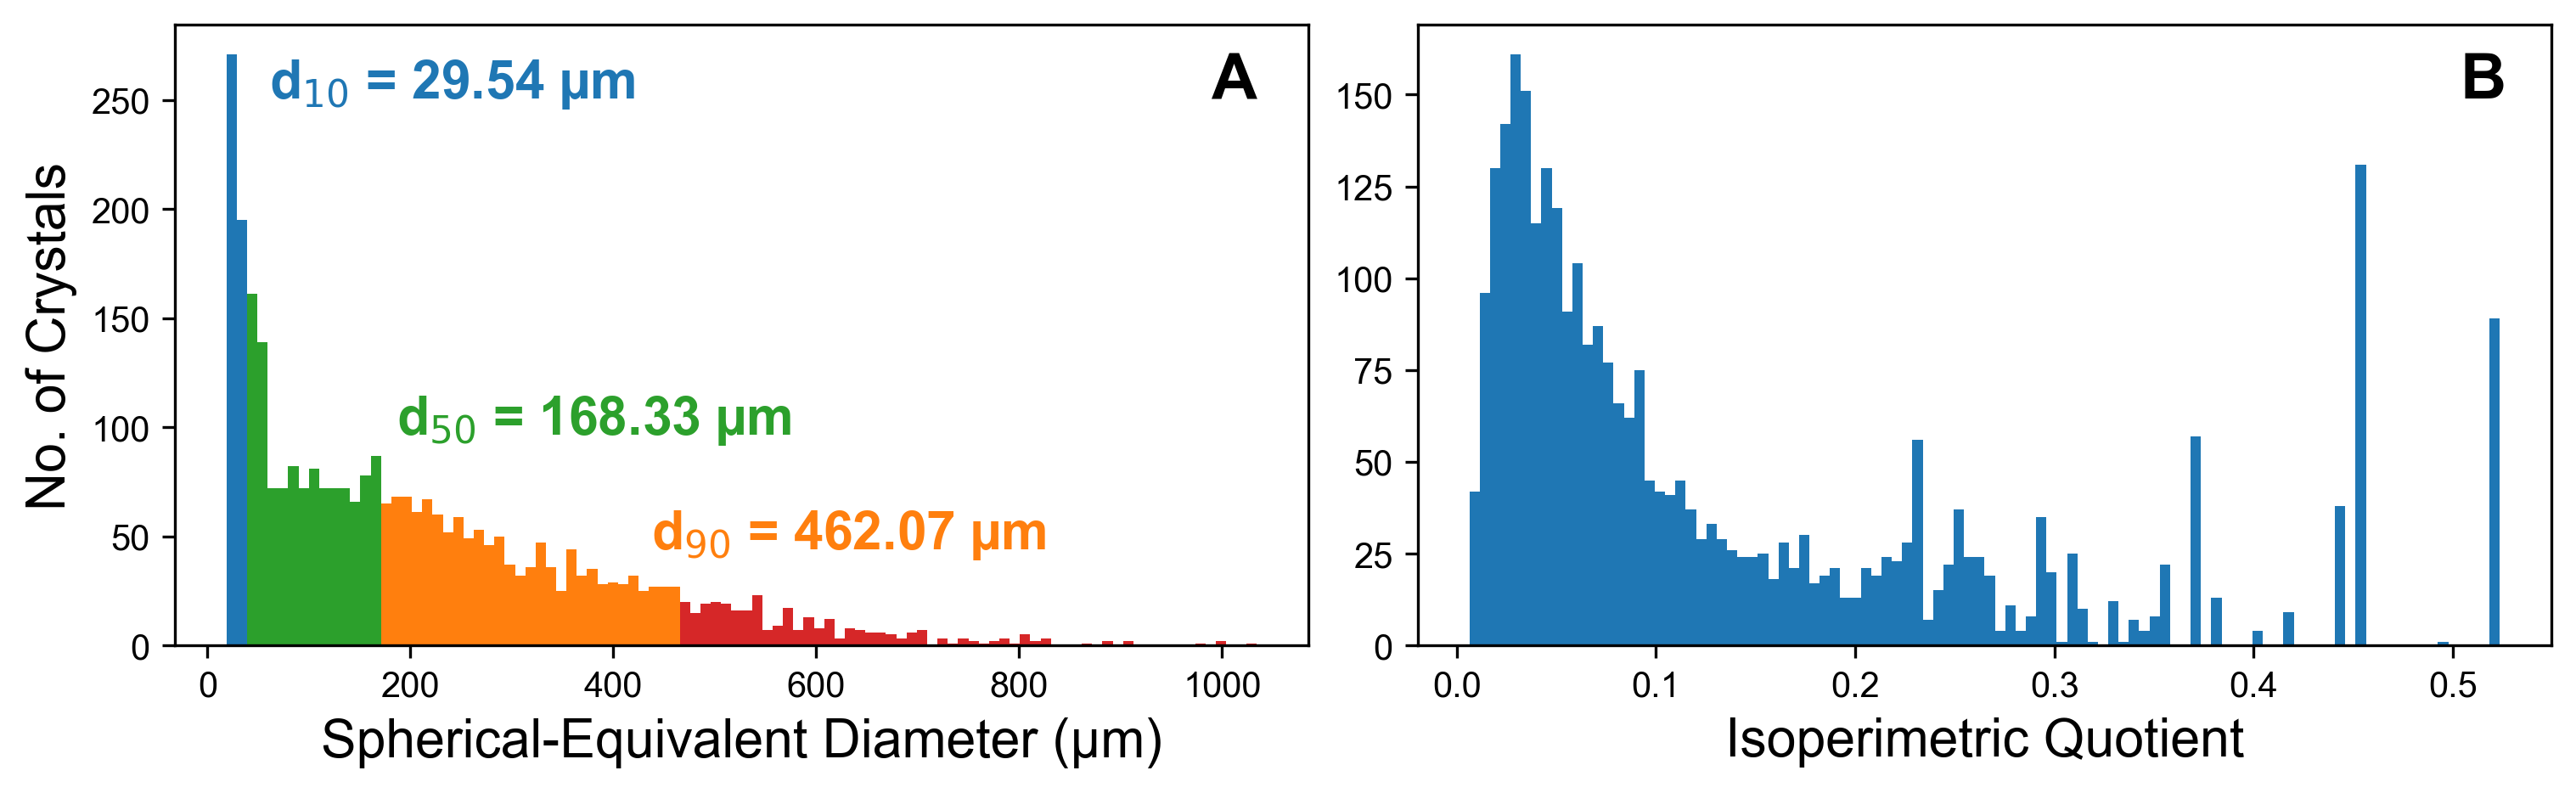

In [44]:
fig, axs = plt.subplots(1, 2, dpi=300, figsize=(10, 3), constrained_layout=True)
counts, bins, patches = axs[0].hist(diameters, bins=100)

for patch in patches:
    if patch.get_x() < d10:
        patch.set_facecolor('tab:blue')
    elif patch.get_x() < d50:
        patch.set_facecolor('tab:green')
    elif patch.get_x() < d90:
        patch.set_facecolor('tab:orange')
    else:
        patch.set_facecolor('tab:red')

axs[0].set_xlabel("Spherical-Equivalent Diameter (µm)", fontsize=15)
axs[0].set_ylabel("No. of Crystals", fontsize=15)
axs[1].hist(list(iqs.values()), bins=100)
axs[1].set_xlabel("Isoperimetric Quotient", fontsize=15)
# axs[1].set_ylabel("No. of Crystals", fontsize=15)
fig.text(0.47, 0.89, "A", fontsize=18, fontweight='bold')
fig.text(0.96, 0.89, "B", fontsize=18, fontweight='bold')
fig.text(0.10, 0.89, f"d$_{{10}}$ = {d10:.2f} µm", fontweight='bold', color='tab:blue', fontsize=15)
fig.text(0.15, 0.45, f"d$_{{50}}$ = {d50:.2f} µm", fontweight='bold', color='tab:green', fontsize=15)
fig.text(0.25, 0.3, f"d$_{{90}}$ = {d90:.2f} µm", fontweight='bold', color='tab:orange', fontsize=15)

# fig.savefig("imgs/6_diameter_iq.png", dpi=300)

In [45]:
sizes = np.bincount(watershed.ravel())[1:] #drop background

In [46]:
import numpy as np

def sample_diverse_large_crystals(iq_dict, sizes, num_samples=5, size_percentile=90):
    """
    Selects a specified number of large crystals with varying IQs.
    
    Parameters:
    - iq_dict: Dictionary mapping crystal label to its IQ.
    - sizes: Array (or dict) where sizes[label] gives the size of that crystal.
    - num_samples: How many crystals to select.
    - size_percentile: The percentile threshold to define a "big" crystal (default 90th).
    """
    
    # 1. Extract the valid labels from your dictionary
    valid_labels = list(iq_dict.keys())
    
    # 2. Extract the sizes for these specific labels
    # (Handles cases where 'sizes' is an array or a dictionary)
    valid_sizes = [sizes[label-1] for label in valid_labels]
    
    # 3. Determine the size threshold for "big" crystals
    # e.g., 90th percentile means keeping the largest 10%
    size_threshold = np.percentile(valid_sizes, size_percentile)
    
    # 4. Filter for only the large crystals
    big_labels = [label for label in valid_labels if sizes[label-1] >= size_threshold]
    
    if not big_labels:
        print("No crystals found meeting the size threshold.")
        return {}

    # 5. Sort the big crystals by their IQ from lowest to highest
    big_labels.sort(key=lambda label: iq_dict[label])
    
    # 6. Select evenly spaced indices to get varying IQs
    if len(big_labels) <= num_samples:
        # If we have fewer big crystals than requested, just take all of them
        selected_indices = range(len(big_labels))
    else:
        # np.linspace generates evenly spaced indices across the array length
        selected_indices = np.linspace(0, len(big_labels) - 1, num_samples, dtype=int)
        
    # 7. Package the results into a clean dictionary
    results = {}
    for idx in selected_indices:
        label = big_labels[idx]
        results[label] = {
            "iq": iq_dict[label],
            "size": sizes[label-1]
        }
        
    return results

# ==========================================
# Example Usage:
# Assuming 'my_iqs' is your dictionary and 'my_sizes' is your array
# ==========================================

# Select 5 crystals from the top 5% largest sizes
# sample_results = sample_diverse_large_crystals(my_iqs, my_sizes, num_samples=5, size_percentile=95)

# for label, data in sample_results.items():
#     print(f"Label {label}: IQ = {data['iq']:.4f}, Size = {data['size']}")

In [75]:
sample_results = sample_diverse_large_crystals(iqs, sizes, num_samples=50, size_percentile=20)

In [76]:
sample_results

{2026: {'iq': np.float64(0.006289085837009991), 'size': np.int64(39752)},
 1792: {'iq': np.float64(0.012201201810869743), 'size': np.int64(1912)},
 420: {'iq': np.float64(0.0149575638317272), 'size': np.int64(1809)},
 1820: {'iq': np.float64(0.01747615732953583), 'size': np.int64(5488)},
 1258: {'iq': np.float64(0.01968449265846216), 'size': np.int64(13819)},
 1781: {'iq': np.float64(0.021277506187487815), 'size': np.int64(8820)},
 857: {'iq': np.float64(0.023202762581336446), 'size': np.int64(5919)},
 2417: {'iq': np.float64(0.025389413640217295), 'size': np.int64(2659)},
 88: {'iq': np.float64(0.026992412282224293), 'size': np.int64(10988)},
 817: {'iq': np.float64(0.028311860908754496), 'size': np.int64(6931)},
 227: {'iq': np.float64(0.030235839123992945), 'size': np.int64(5550)},
 557: {'iq': np.float64(0.03192522004494748), 'size': np.int64(42771)},
 312: {'iq': np.float64(0.034078682551654235), 'size': np.int64(10175)},
 661: {'iq': np.float64(0.03558057510779706), 'size': np.in

In [77]:
np.where(watershed==3105)

(array([1758, 1759, 1759, 1759, 1759, 1759, 1759, 1759, 1759, 1760, 1760,
        1760, 1760, 1760, 1760, 1760, 1760, 1760, 1760, 1761, 1761, 1761,
        1761, 1761, 1761]),
 array([362, 361, 361, 361, 362, 362, 362, 363, 363, 361, 361, 361, 361,
        362, 362, 362, 362, 363, 363, 361, 361, 361, 362, 362, 362]),
 array([615, 614, 615, 616, 614, 615, 616, 614, 615, 613, 614, 615, 616,
        613, 614, 615, 616, 614, 615, 614, 615, 616, 614, 615, 616]))

In [78]:
napari.view_image((watershed == 3105).astype(int)[1750:1765, 360:365, 610:620])

Viewer(camera=Camera(center=(0.0, np.float64(2.0), np.float64(4.5)), zoom=np.float64(84.36), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(7.0), 1.0, 0.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=3, ndisplay=2, order=(0, 1, 2), axis_labels=('0', '1', '2'), rollable=(True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(14.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(4.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(9.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0), point=(np.float64(7.0), np.float64(2.0), np.float64(4.0)), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False, spacing=0.0), layers=[<Image lay